# Customer Churn Analysis

## Database Setup & Extraction

In [33]:
import pandas as pd
import sqlite3

In [34]:
raw_df = pd.read_csv('customer_churn_dataset.csv')
conn = sqlite3.connect('churn_project.db')

In [35]:
raw_df.columns = raw_df.columns.str.replace(' ', '_')
raw_df.to_sql('customer_data', conn, if_exists='replace', index=False)

440833

In [36]:
query = """
    SELECT 
        CustomerID, 
        Age, 
        Gender, 
        Tenure, 
        Total_Spend, 
        Payment_Delay, 
        Churn
    FROM 
        customer_data
    WHERE 
        CustomerID IN (
            -- Inner subquery 1: Find users with high payment delays
            SELECT CustomerID 
            FROM customer_data 
            WHERE Payment_Delay > (
                SELECT AVG(Payment_Delay) 
                FROM customer_data
            )
        )
        AND Total_Spend > (
            -- Inner subquery 2: Find users who spend more than average
            SELECT AVG(Total_Spend)
            FROM customer_data
        );
"""

In [37]:
extracted_data = pd.read_sql_query(query, conn)

In [38]:
conn.close()

In [15]:
extracted_data.head()

,CustomerID,Age,Gender,Tenure,Total_Spend,Payment_Delay,Churn
0,2.0,30.0,Female,39.0,932.0,18.0,1.0
1,9.0,58.0,Female,49.0,821.0,16.0,1.0
2,13.0,29.0,Male,18.0,930.0,30.0,1.0
3,14.0,52.0,Female,21.0,830.0,26.0,1.0
4,18.0,49.0,Male,56.0,975.0,30.0,1.0


## Statistical Summary & Data Integrity Check

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = extracted_data

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112822 entries, 0 to 112821
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   CustomerID     112822 non-null  float64
 1   Age            112822 non-null  float64
 2   Gender         112822 non-null  object 
 3   Tenure         112822 non-null  float64
 4   Total_Spend    112822 non-null  float64
 5   Payment_Delay  112822 non-null  float64
 6   Churn          112822 non-null  float64
dtypes: float64(6), object(1)
memory usage: 6.0+ MB


In [24]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [19]:
df.shape

(112822, 7)

In [21]:
df.describe()

,CustomerID,Age,Tenure,Total_Spend,Payment_Delay,Churn
count,112822.000000,112822.000000,112822.000000,112822.000000,112822.000000,112822.000000
mean,235073.781461,39.135851,31.298355,815.334406,19.241531,0.522939
std,130144.836278,12.294567,17.233502,106.477877,4.827135,0.499476
min,2.000000,18.000000,1.000000,631.640000,13.000000,0.000000
25%,123026.000000,29.000000,16.000000,723.152500,15.000000,0.000000
50%,244458.500000,39.000000,32.000000,814.330000,18.000000,1.000000
75%,348163.500000,48.000000,46.000000,908.000000,22.000000,1.000000
max,449996.000000,65.000000,60.000000,1000.000000,30.000000,1.000000


In [25]:
df.isna().sum()

CustomerID       0
Age              0
Gender           0
Tenure           0
Total_Spend      0
Payment_Delay    0
Churn            0
dtype: int64

In [28]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(f"\n--- Baseline Churn Rate ---")
print(f"Retained (0): {churn_rate[0]:.2f}%")
print(f"Churned (1): {churn_rate[1]:.2f}%")


--- Baseline Churn Rate ---
Retained (0): 47.71%
Churned (1): 52.29%


## Univariate & Bivariate Analysis

C:\Users\bordo\AppData\Local\Temp\ipykernel_17800\1864451467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, x='Churn', y='Total_Spend', palette='Set2')
C:\Users\bordo\AppData\Local\Temp\ipykernel_17800\1864451467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='Churn', y='Payment_Delay', palette='Set1')


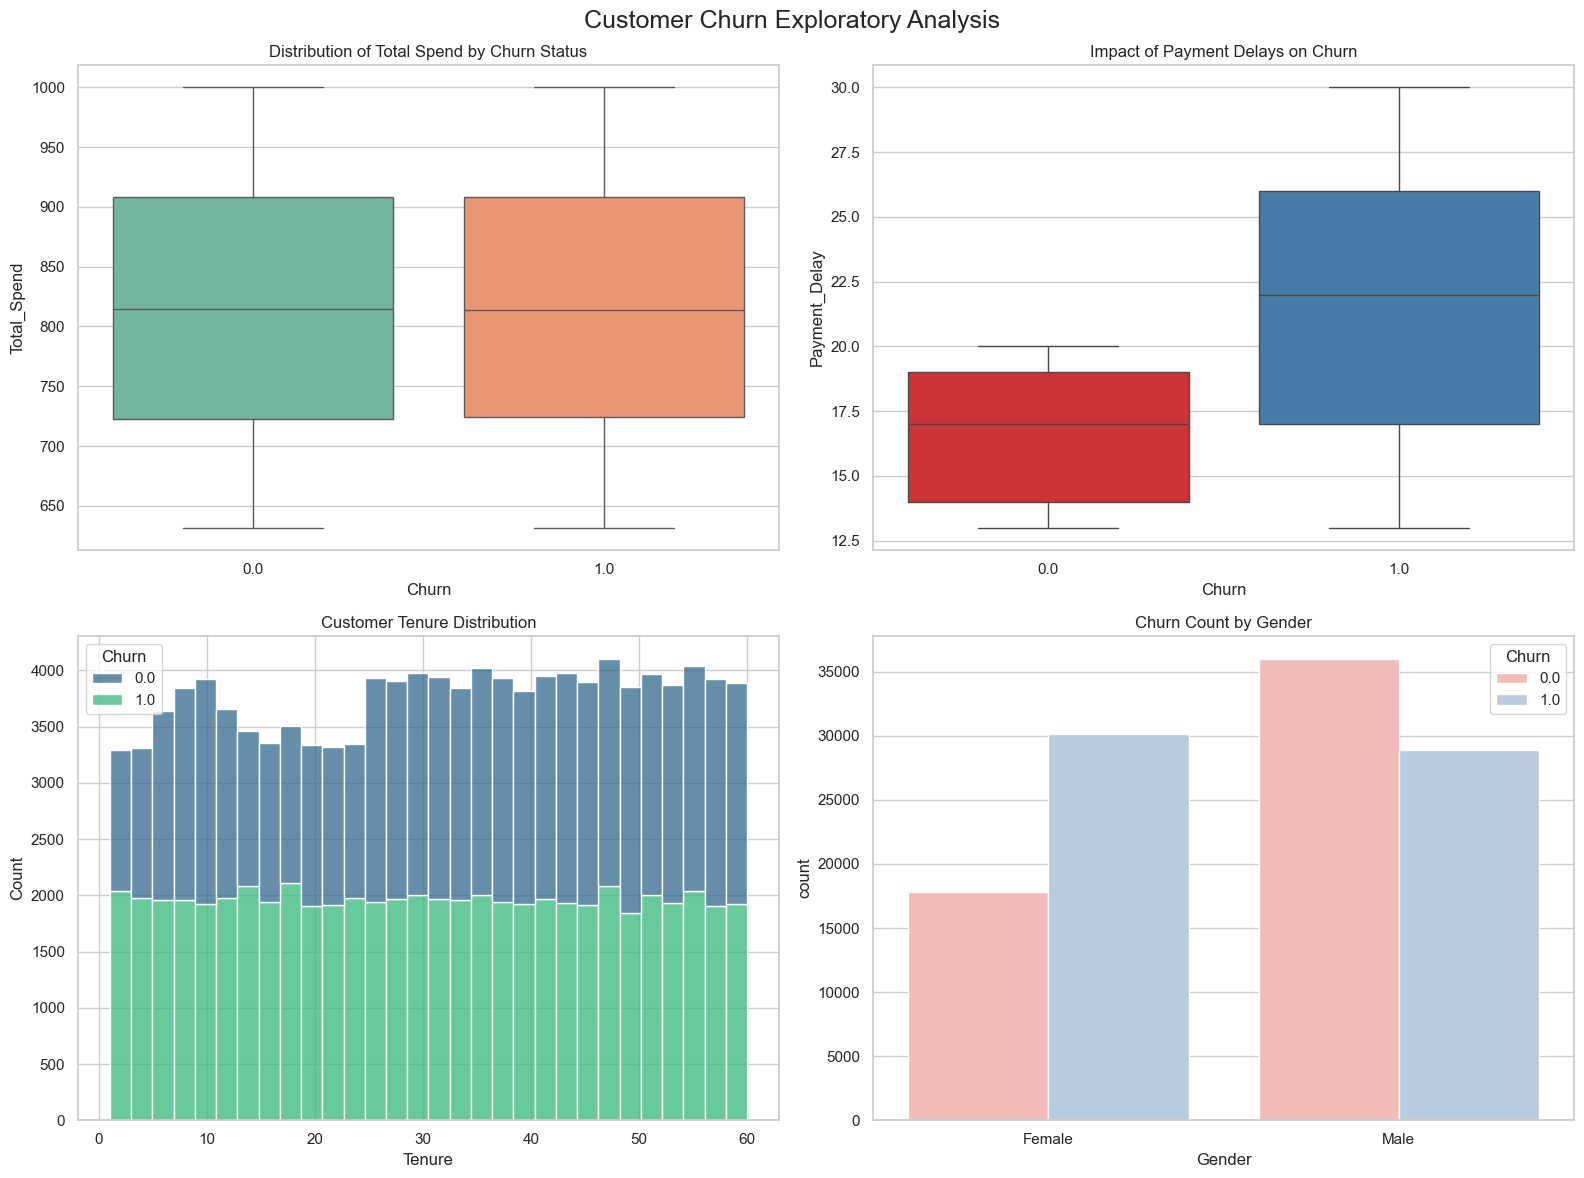

In [29]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Churn Exploratory Analysis', fontsize=18)

# 1. Total Spend vs Churn
sns.boxplot(ax=axes[0, 0], data=df, x='Churn', y='Total_Spend', palette='Set2')
axes[0, 0].set_title('Distribution of Total Spend by Churn Status')

# 2. Payment Delay vs Churn
sns.boxplot(ax=axes[0, 1], data=df, x='Churn', y='Payment_Delay', palette='Set1')
axes[0, 1].set_title('Impact of Payment Delays on Churn')

# 3. Tenure Distribution (How long do customers stay?)
sns.histplot(ax=axes[1, 0], data=df, x='Tenure', hue='Churn', multiple='stack', bins=30, palette='viridis')
axes[1, 0].set_title('Customer Tenure Distribution')

# 4. Gender vs Churn (Categorical Comparison)
sns.countplot(ax=axes[1, 1], data=df, x='Gender', hue='Churn', palette='Pastel1')
axes[1, 1].set_title('Churn Count by Gender')

plt.tight_layout()
plt.show()

## Correlation Analysis

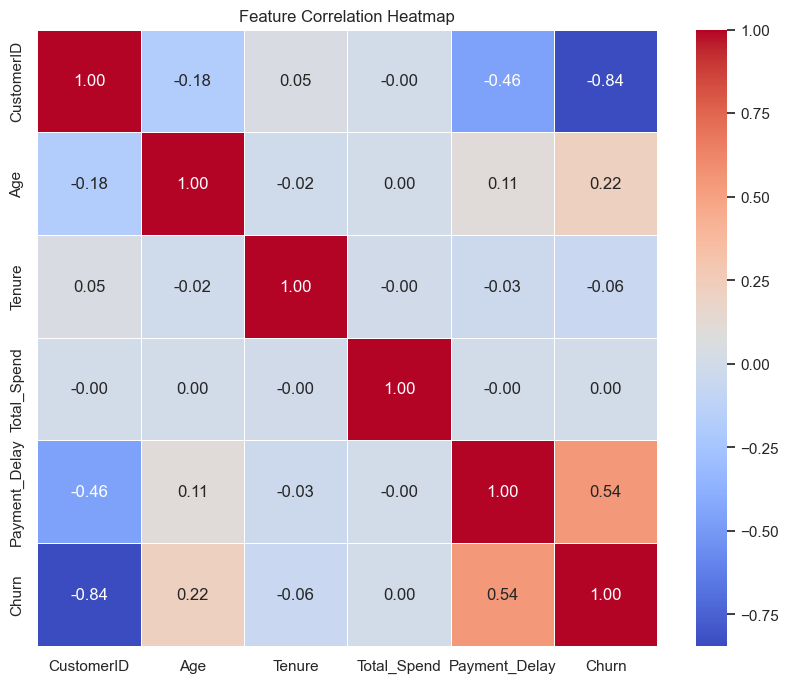

In [30]:
numerical_df = df.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()